In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from  tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Embedding, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [4]:
df=pd.read_csv("spam.csv",encoding='latin-1')
df=df[['v1' , 'v2']]
df.columns=['label' ,'text']

print(f"Dataset Shape: {df.shape}")
print("\nClass Distribution:\n",df['label'].value_counts())

encoder=LabelEncoder()
df['label']=encoder.fit_transform(df['label'])

Dataset Shape: (5572, 2)

Class Distribution:
 label
ham     4825
spam     747
Name: count, dtype: int64


In [5]:
x_train, x_test, y_train, y_test= train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

MAX_WORDS=5000
MAX_LEN=50
EMBEDDING_DTM=64

tokenizer= Tokenizer(num_words=MAX_WORDS, oov_token="<oov>")
tokenizer.fit_on_texts(x_train)

x_train_seq= tokenizer.texts_to_sequences(x_train)
x_test_seq= tokenizer.texts_to_sequences(x_test)

x_train_pad=pad_sequences(x_train_seq, maxlen=MAX_LEN, padding='post')
x_test_pad=pad_sequences(x_test_seq, maxlen=MAX_LEN, padding='post')


In [14]:
model = Sequential([
    Input(shape=(MAX_LEN,)),  

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DTM
    ),

    GRU(
        units=64,
        dropout=0.2,
        recurrent_dropout=0.2
    ),

    Dense(1, activation='sigmoid')  
])


model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 50, 64)              │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 64)                  │          24,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 345,025 (1.32 MB)

 Trainable params: 345,025 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\nStarting Model Training...")
history = model.fit(
    x_train_pad, y_train,
    epochs=4,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)


Starting Model Training...
Epoch 1/4
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 124ms/step - accuracy: 0.8656 - loss: 0.4237 - val_accuracy: 0.8453 - val_loss: 0.4362
Epoch 2/4
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.8681 - loss: 0.3959 - val_accuracy: 0.8453 - val_loss: 0.4339
Epoch 3/4
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.8681 - loss: 0.3936 - val_accuracy: 0.8453 - val_loss: 0.4286
Epoch 4/4
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.8848 - loss: 0.3121 - val_accuracy: 0.9776 - val_loss: 0.1067


In [8]:
print("\nEvaluating Model on Test Data...")
loss, accuracy = model.evaluate(x_test_pad, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

y_pred_probs = model.predict(x_test_pad)
y_pred = (y_pred_probs > 0.5).astype(int)





Evaluating Model on Test Data...
Test Loss: 0.1231
Test Accuracy: 97.22%
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step


In [9]:
from sklearn.metrics import classification_report

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))


Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.98       966
        Spam       0.92      0.87      0.89       149

    accuracy                           0.97      1115
   macro avg       0.95      0.93      0.94      1115
weighted avg       0.97      0.97      0.97      1115



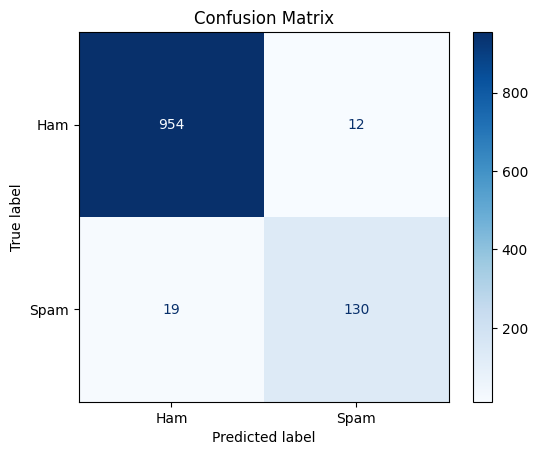

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [11]:
def filter_incoming_sms(message_text):
   
    seq = tokenizer.texts_to_sequences([message_text])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    
   
    probability = model.predict(padded, verbose=0)[0][0]
    
   
    if probability > 0.5:
        return f"[SPAM ALERT ({probability*100:.1f}% Match)] -> Sent to Spam Folder."
    else:
        return f"[INBOX (Legitimate)] -> {message_text}"





In [12]:
def predict_multiple_sms(messages_list):
    print("\n--- Batch SMS Prediction ---")
    for msg in messages_list:
        seq = tokenizer.texts_to_sequences([msg])
        padded = pad_sequences(seq, maxlen=MAX_LEN)
        probability = model.predict(padded, verbose=0)[0][0]
        
        if probability > 0.5:
            result = f"SPAM ({probability*100:.1f}%)"
        else:
            result = f"HAM ({probability*100:.1f}%)"
            
        print(f"Message: \"{msg}\" ---> Result: {result}")

In [13]:
test_messages = [
    "CONGRATULATIONS! You won a $1,000 Walmart Gift Card! Click this link to claim it now: http://bit.ly",
    "Hey, are we still meeting for lunch today at 1 PM?",
    "URGENT! Your mobile account has won £2000 cash prize. Call 09066361531 to claim."
]

predict_multiple_sms(test_messages)


--- Batch SMS Prediction ---
Message: "CONGRATULATIONS! You won a $1,000 Walmart Gift Card! Click this link to claim it now: http://bit.ly" ---> Result: HAM (4.3%)
Message: "Hey, are we still meeting for lunch today at 1 PM?" ---> Result: HAM (1.7%)
Message: "URGENT! Your mobile account has won £2000 cash prize. Call 09066361531 to claim." ---> Result: HAM (48.8%)


In [15]:
single_test_msg = df['text'].iloc[10]
seq = tokenizer.texts_to_sequences([single_test_msg])
padded = pad_sequences(seq, maxlen=MAX_LEN)
probability = model.predict(padded, verbose=0)[0][0]

if probability > 0.5:
    result = "SPAM"
else:
    result = "HAM"

print(f"Message: \"{single_test_msg}\"")
print(f"Result: {result}")

Message: "I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."
Result: HAM


In [16]:
single_test_msg = df['text'].iloc[5] 

seq = tokenizer.texts_to_sequences([single_test_msg])
padded = pad_sequences(seq, maxlen=MAX_LEN)
probability = model.predict(padded, verbose=0)[0][0]

if probability > 0.5:
    result = "SPAM"
else:
    result = "HAM"

print(f"Message: \"{single_test_msg}\"")
print(f"Result: {result}")

Message: "FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv"
Result: HAM
